## Gene Embedding Analysis Tutorial

Creator : Adib Miraki (am74@sanger.ac.uk).

Affiliation: Wellcome Sanger Institute, Lotfollahi Lab

Date of Creation: 27.08.2025

In this notebook, we will explore gene embeddings as an approach for de novo gene program discovery. The genes identified in these programs may also serve as potential candidates for perturbation studies.
To illustrate this, we will construct a new AnnData object derived from the gene embeddings. In this object, each obs_name corresponds to a gene at a specific timepoint, and the matrix X stores the embedding values for that gene.

1.Setup

In [1]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [3]:
adata = sc.read('/lustre/scratch126/cellgen/lotfollahi/dv8/trace/T_perturb/cytomeister/plt/res/lps/embedding_100mMedE0e7_int_2k_all_tps_lps/embeddings/20250715-12:10_inference_embs_t[1, 2, 3]_scmaskgit_mcosine.h5ad')

Optionally, cell embeddings can be used for neighbor calculations and UMAP visualization.

In [5]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


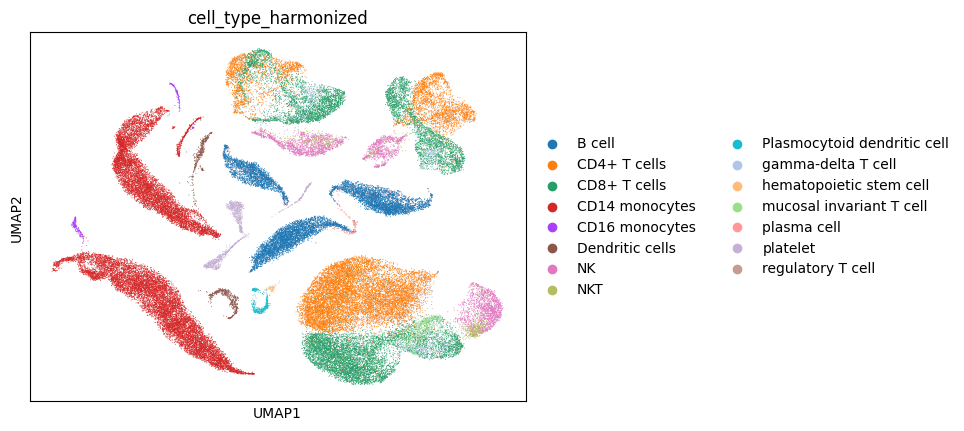

In [4]:
sc.pp.neighbors(adata,use_rep='cls_embeddings')
sc.tl.umap(adata)
sc.pl.umap(adata,color='cell_type_harmonized')

At this step, we use the original data to get a mapping dictionary so we can translate the Ensembl IDs in the gene embedding object into readable gene symbols.

In [6]:
adata_full = sc.read('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/full_lps.h5ad')

In [7]:
adata_full.X.max()

np.float32(4066.0)

In [8]:
sc.pp.normalize_total(adata_full)
sc.pp.log1p(adata_full)

In [9]:
sc.pp.neighbors(adata_full)
sc.tl.umap(adata_full)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 13826 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [10]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [11]:
sc.set_figure_params(dpi_save=600)

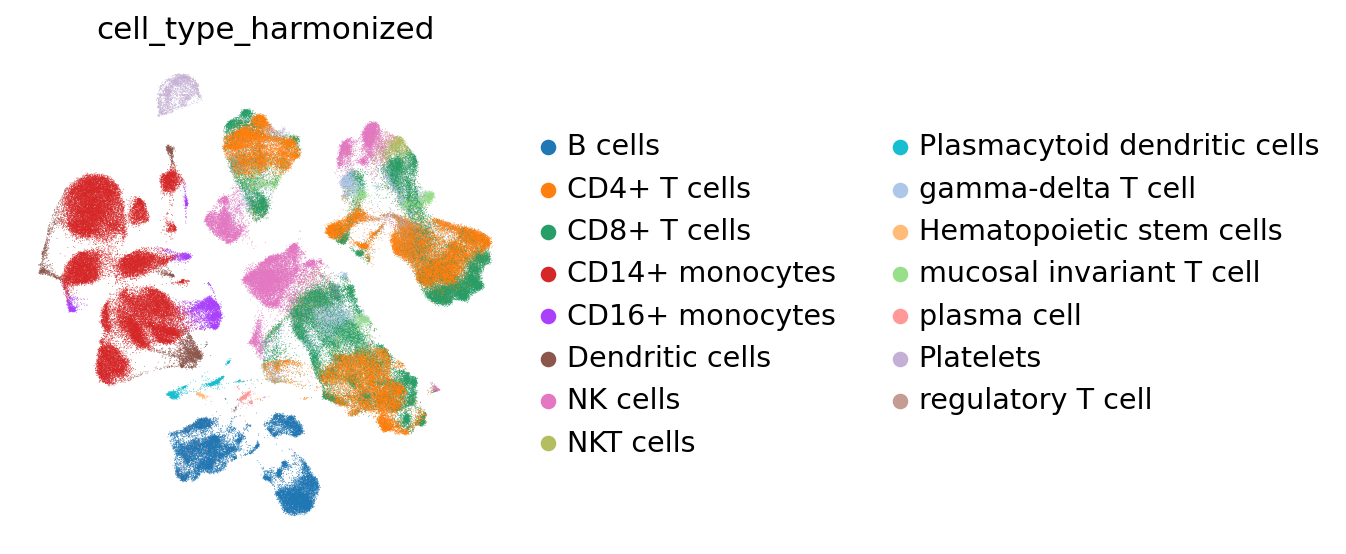

In [12]:

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap(
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


In [13]:
adata.var['gene_symbol'] = adata.var.index.map(adata_full.var['gene_symbol-0'])

Now we build a new object for the gene embeddings. Here, every gene is treated like a cell, but instead of expression values we use its 768-dimensional embedding vector. With this object, you can easily run UMAP and perform clustering.

In [14]:

gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

In [15]:
adata_full.var_names = adata_full.var['gene_ids-0']

2.Remove Genes with all 0 values

In [16]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


Number of gene-timepoint vectors with all-zero values: 37


In [17]:
new_adata = new_adata[~zero_mask].copy()

In [18]:
sc.pp.neighbors(new_adata)
sc.tl.umap(new_adata)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


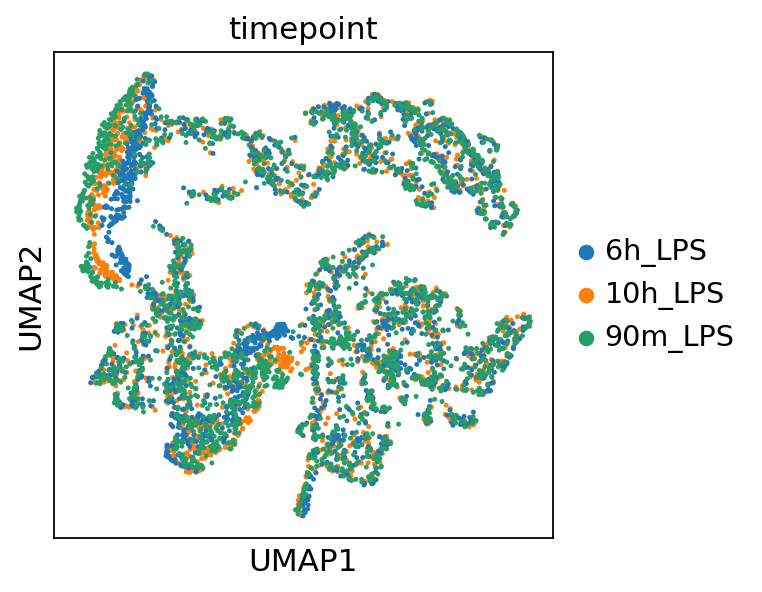

In [19]:
sc.pl.umap(new_adata,color='timepoint')

In [20]:
new_adata.uns['timepoint_colors']

['#1f77b4', '#ff7f0e', '#279e68']

In [21]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1')

/tmp/ipykernel_2745026/1903070418.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(new_adata,resolution=1,key_added='r1')


3.For annotating gene programs, we recommend using predefined gene sets as guidance.


In [24]:
results = {}

for cluster in new_adata.obs['r1'].unique():
    cluster_genes = new_adata.obs.loc[new_adata.obs['r1'] == cluster, 'gene_symbol'].tolist()
    
    enr = gp.enrichr(
        gene_list=cluster_genes,
        gene_sets= ['GO_Biological_Process_2025','Reactome_Pathways_2024'],
        
        organism='Human',              
        outdir=None,                  
        cutoff=0.5                     
    )
    
    results[cluster] = enr.results.sort_values('Adjusted P-value').head(5)

for cluster, df in results.items():
    print(f"\nCluster {cluster} - Top 5 Enriched Terms:")
    print(df[['Term', 'Overlap', 'Adjusted P-value']])



Cluster 4 - Top 5 Enriched Terms:
                                                   Term  Overlap  \
0     Positive Regulation of Response to External St...    8/163   
1     Negative Regulation of DNA-templated Transcrip...  19/1006   
2                    Inflammatory Response (GO:0006954)    9/261   
3     Negative Regulation of Transcription by RNA Po...   15/732   
1070                       Attachment and Entry 9694614     4/26   

      Adjusted P-value  
0             0.003521  
1             0.003521  
2             0.007174  
3             0.007174  
1070          0.007333  

Cluster 9 - Top 5 Enriched Terms:
                                                   Term  Overlap  \
1082                                      Immune System  38/2150   
1083                Cytokine Signaling in Immune System   19/776   
1084                               Innate Immune System  22/1149   
0     Positive Regulation of Tumor Necrosis Factor S...     7/85   
1     Regulation of Tumor Necro

In [28]:
list(new_adata[new_adata.obs['r1']=='6'].obs['gene_symbol'])

['SH3BGRL3',
 'YBX1',
 'JUN',
 'IFI44L',
 'S100A10',
 'S100A11',
 'S100A9',
 'S100A12',
 'S100A8',
 'S100A6',
 'S100A4',
 'RPS27',
 'MNDA',
 'FCER1G',
 'FCGR3A',
 'CD247',
 'CALM2',
 'TMSB10',
 'GNLY',
 'CXCR4',
 'SLC4A10',
 'FGFBP2',
 'CXCL8',
 'PPBP',
 'CXCL10',
 'SPP1',
 'IL7R',
 'GZMK',
 'GZMA',
 'CD14',
 'PPP2R2B',
 'CD74',
 'DUSP1',
 'HSP90AB1',
 'EEF1A1',
 'ACTB',
 'CPVL',
 'LYPD2',
 'ANXA1',
 'FCN1',
 'PTGDS',
 'VIM',
 'SKIDA1',
 'SRGN',
 'PRF1',
 'IFITM3',
 'MS4A6A',
 'FTH1',
 'CFL1',
 'PTPRCAP',
 'GSTP1',
 'CD3E',
 'CD3D',
 'GAPDH',
 'KLRB1',
 'CD69',
 'CLEC9A',
 'KLRD1',
 'PLBD1',
 'TUBA1B',
 'CD63',
 'RPS26',
 'MYL6',
 'LYZ',
 'DUSP6',
 'RPLP0',
 'HMGB1',
 'F7',
 'GZMH',
 'GZMB',
 'RPS29',
 'FOS',
 'HSP90AA1',
 'CRIP1',
 'SERF2',
 'ANXA2',
 'RPLP1',
 'IL32',
 'MT2A',
 'CYBA',
 'EIF4A1',
 'CD68',
 'RPL38',
 'OAZ1',
 'JUNB',
 'IFI30',
 'TYROBP',
 'FTL',
 'NKG7',
 'CST3',
 'CST7',
 'LGALS1',
 'SYCE3',
 'TMSB4X',
 'SAT1',
 'CYBB',
 'CFP',
 'RPS4Y1',
 'SH3BGRL3',
 'YBX1',
 'JUN'

In [29]:
genes_cluster_6 = list(new_adata[new_adata.obs['r1']=='6'].obs['gene_symbol'])

genes_present = [g for g in genes_cluster_6 if g in adata_full.var_names]

sc.tl.score_genes(adata_full, gene_list=genes_present, score_name='Cytokine Signaling')

In [34]:
cluster_map = {
    '6': 'Cytokine Signaling',
}

new_adata.obs['MoA'] = new_adata.obs['r1'].map(cluster_map).fillna('Others')


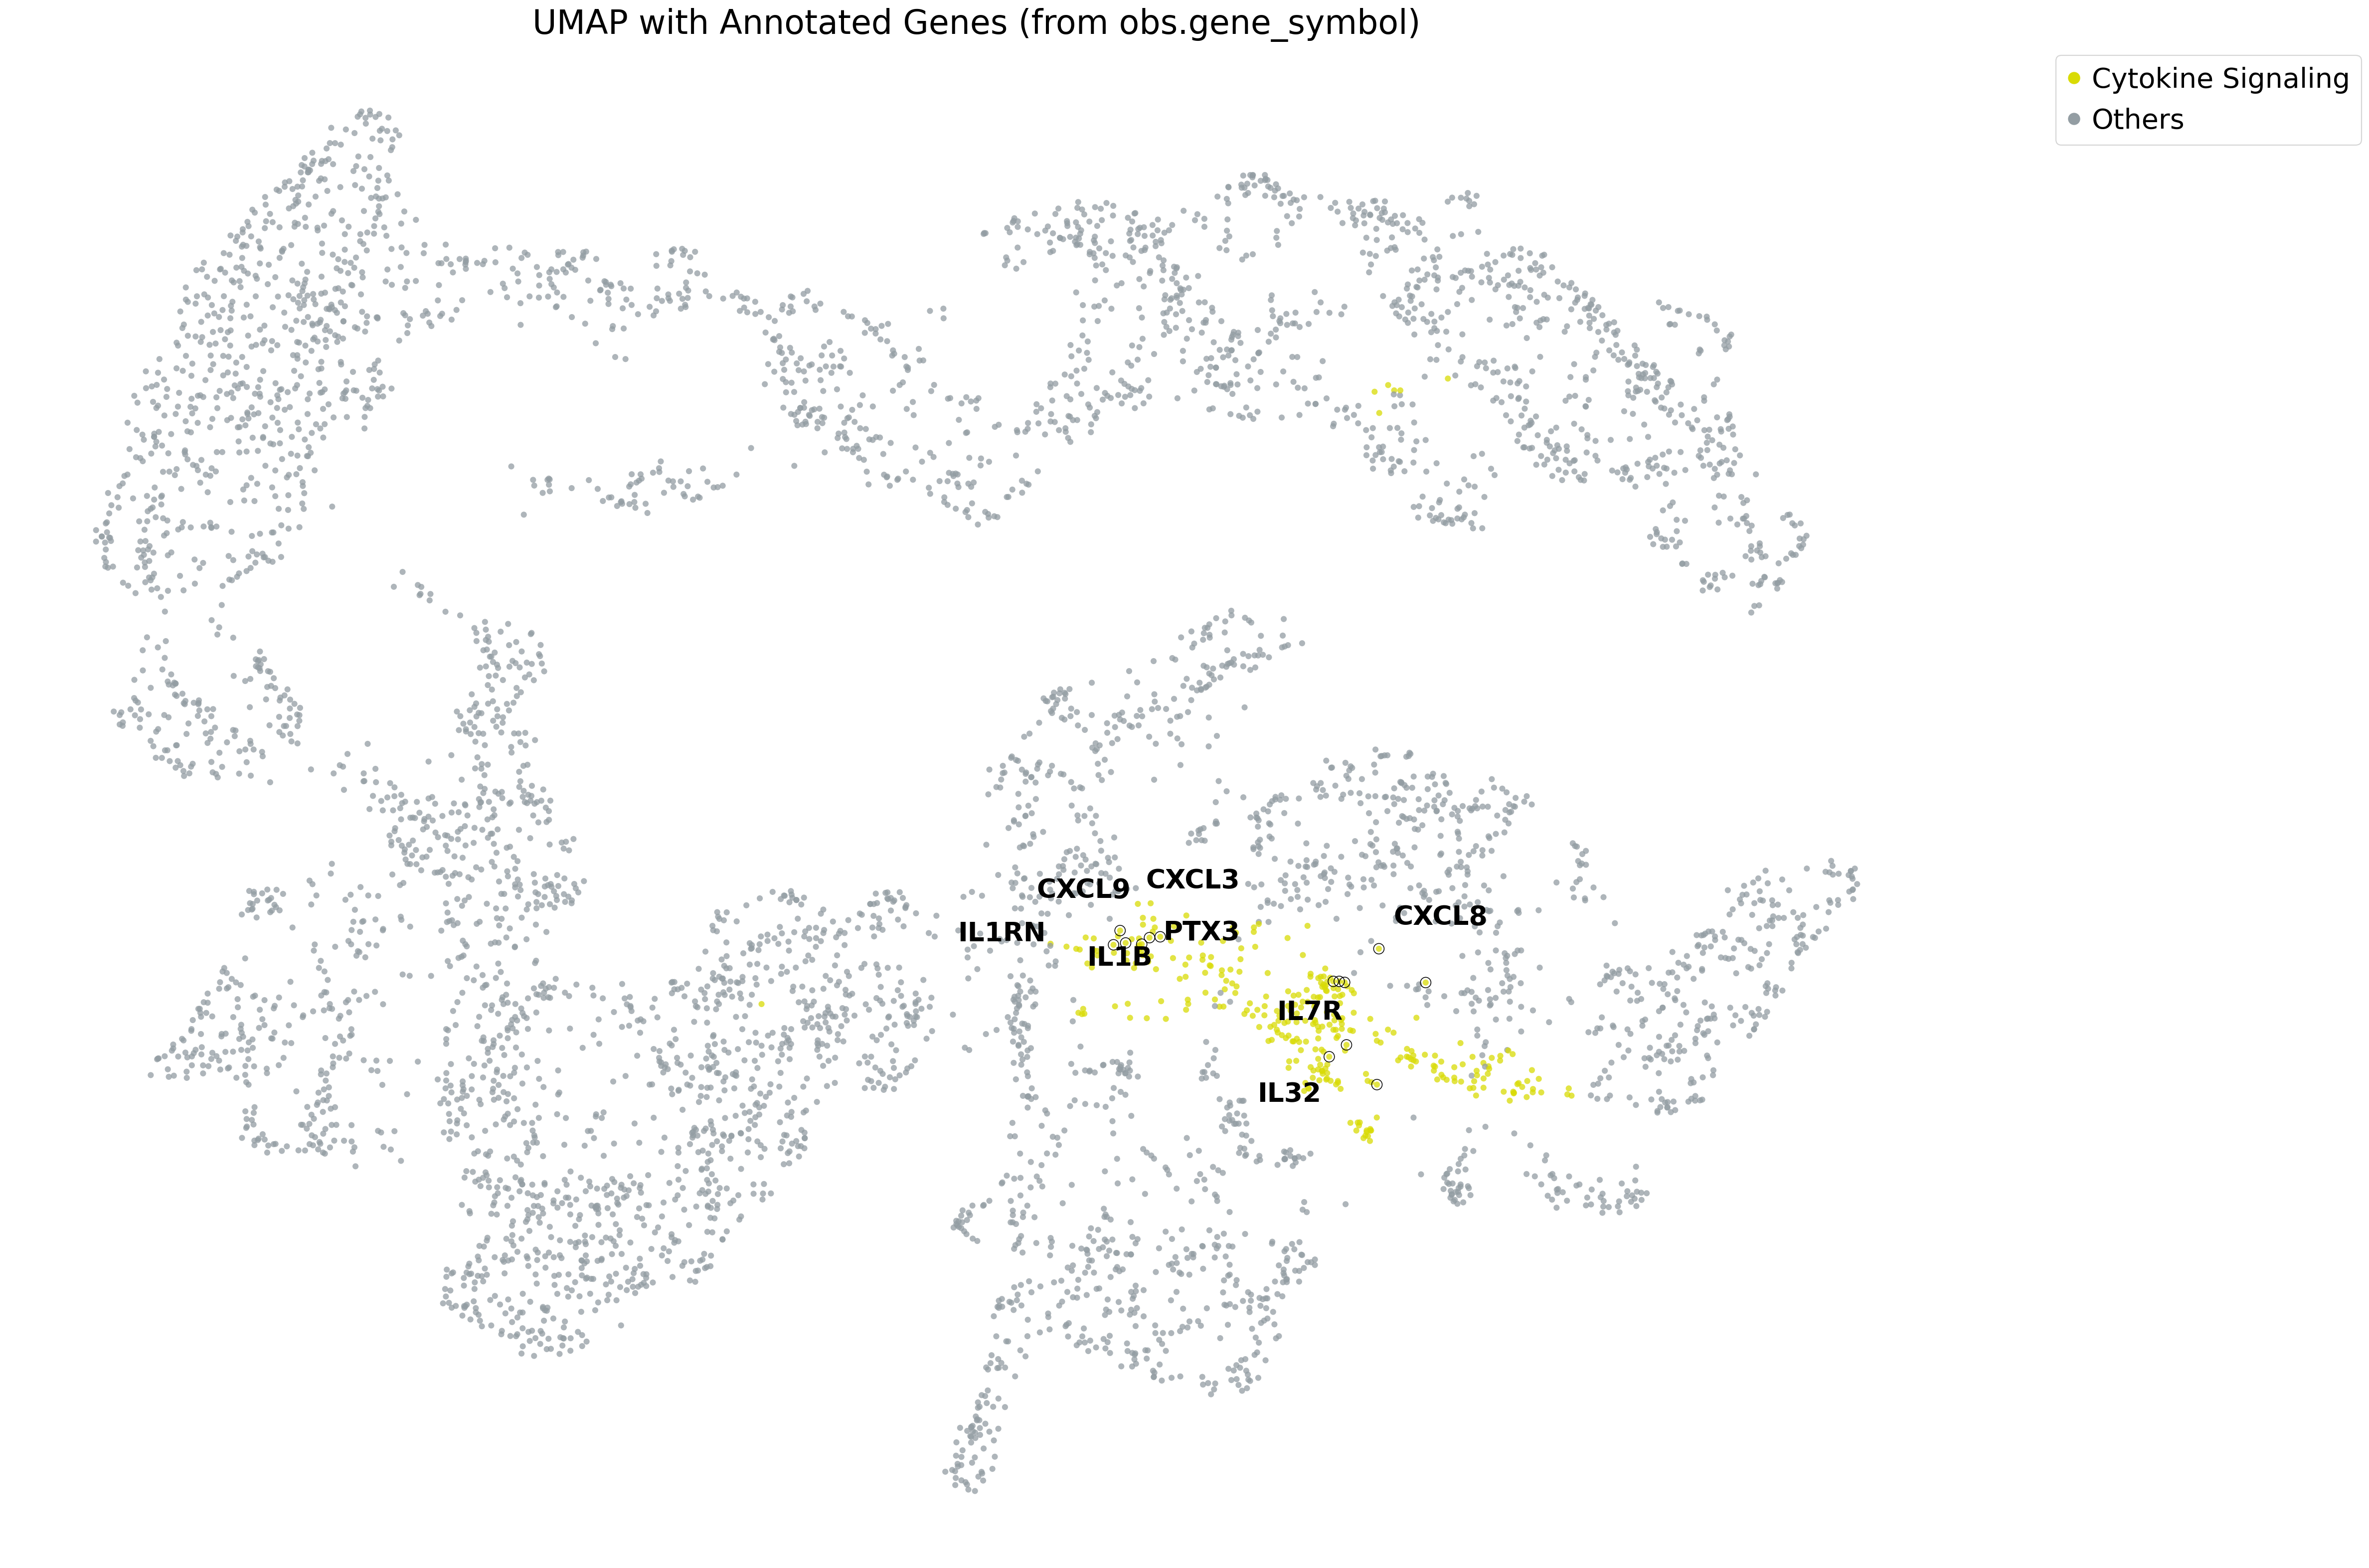

In [41]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(30, 20))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes (from obs.gene_symbol)', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig('umap_highlight_gene_symbol.png', dpi=600)
plt.show()


/tmp/ipykernel_2745026/3355654918.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cell_type_harmonized')['Cytokine Signaling']
/tmp/ipykernel_2745026/3355654918.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


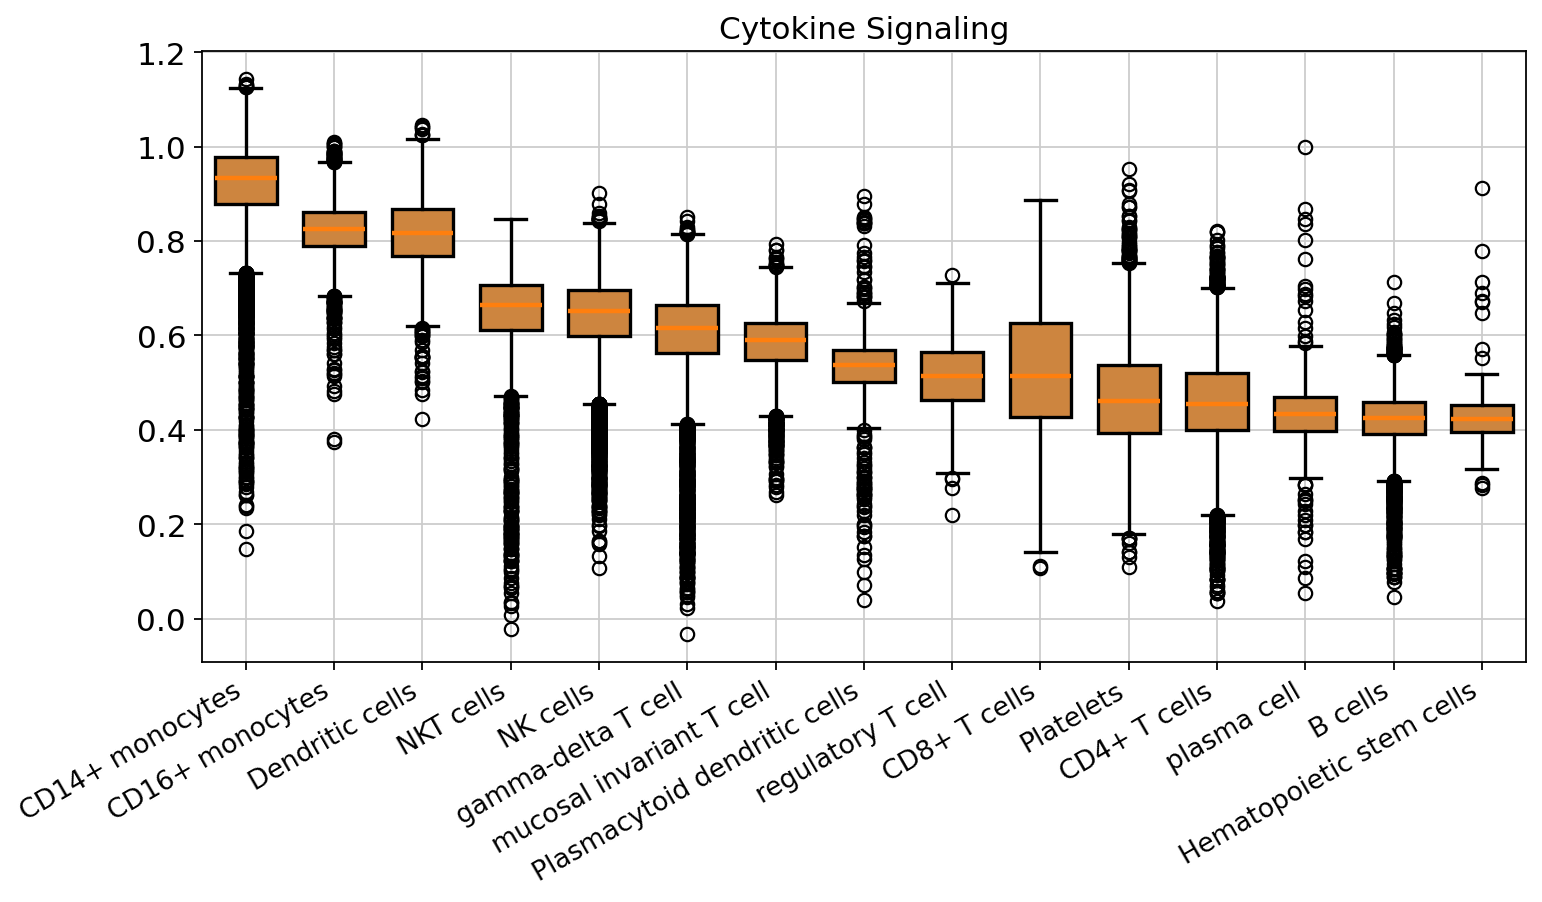

In [43]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig("./cytokine_signaling_boxplot.png", dpi=600, bbox_inches='tight', format='pdf')
plt.show()


In [44]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [45]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]


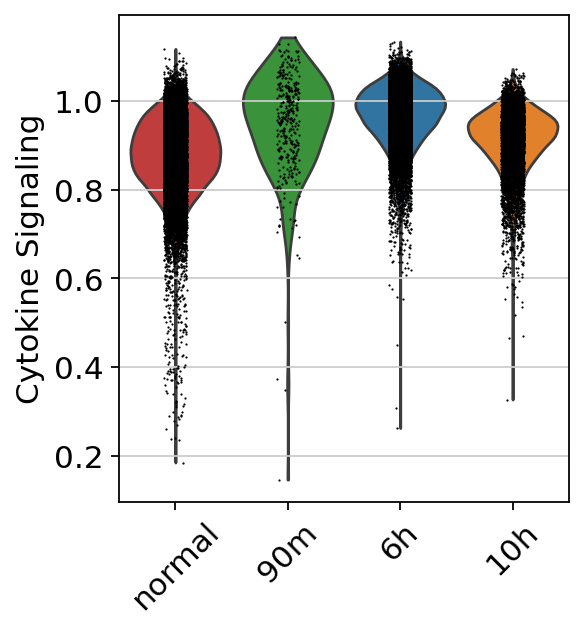

In [46]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png')